In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import count, avg, col, regexp_replace, substring_index, lower, trim
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from pyspark.ml.feature import Word2Vec, Tokenizer, StopWordsRemover, StringIndexer
from pyspark.ml import Pipeline
from pyspark.sql.functions import (
    length, split, size, when, expr, sum as Fsum
)
from pyspark.sql.functions import round as Fround
from pyspark.sql.functions import lit
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

from pyspark.ml.classification import GBTClassifier
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import BinaryClassificationEvaluator


spark = (SparkSession.builder
         .appName("Books EDA")
         .config("spark.driver.memory", "8g")
         .getOrCreate())

ratings_df = spark.read.parquet(
    "/content/drive/MyDrive/Data_mining/clean/ratings_clean.parquet"
)

books_df = spark.read.parquet(
    "/content/drive/MyDrive/Data_mining/clean/books_clean.parquet"
)


# Q1: Does the number of reviews predict rating?

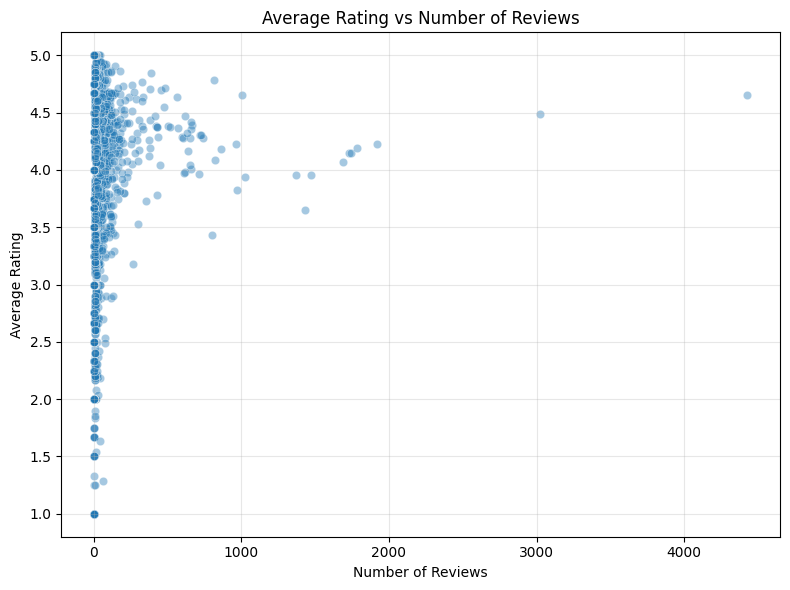

In [ ]:
book_level = (
    ratings_df
    .groupBy("Title")
    .agg(
        count("*").alias("num_reviews"),
        avg("review_score_num").alias("avg_rating")
    )
)

book_level_pd = book_level.sample(fraction=0.05, seed=42).toPandas()

plt.figure(figsize=(8,6))
sns.scatterplot(
    x="num_reviews",
    y="avg_rating",
    data=book_level_pd,
    alpha=0.4
)

plt.xlabel("Number of Reviews")
plt.ylabel("Average Rating")
plt.title("Average Rating vs Number of Reviews")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



In [ ]:
book_level_pd[["num_reviews", "avg_rating"]].corr(method="pearson")


,num_reviews,avg_rating
num_reviews,1.000000,-0.008237
avg_rating,-0.008237,1.000000


In [ ]:
book_level_pd[["num_reviews", "avg_rating"]].corr(method="spearman")


,num_reviews,avg_rating
num_reviews,1.000000,-0.224161
avg_rating,-0.224161,1.000000


Exploratory analysis reveals no strong linear relationship between the number of reviews and the average rating of a book (Pearson r ≈ 0). A weak negative monotonic relationship is observed (Spearman ρ ≈ −0.22), suggesting that as the number of reviews increases, ratings tend to stabilize around a common mean. Books with few reviews exhibit high rating variability, whereas highly reviewed books show more consistent ratings.

# Q2: Do more expensive books receive higher ratings?

In [ ]:
ratings_df = ratings_df.withColumn(
    "Clean_Price",
    regexp_replace(col("Price"), "[$,]", "").cast("double")
)


In [ ]:
book_level = (
    ratings_df
    .filter(col("Clean_Price").isNotNull())
    .groupBy("Title")
    .agg(
        avg("review_score_num").alias("avg_rating"),
        avg("Clean_Price").alias("avg_price"),
        count("*").alias("num_reviews")
    )
)

book_level = book_level.filter(col("num_reviews") >= 5)


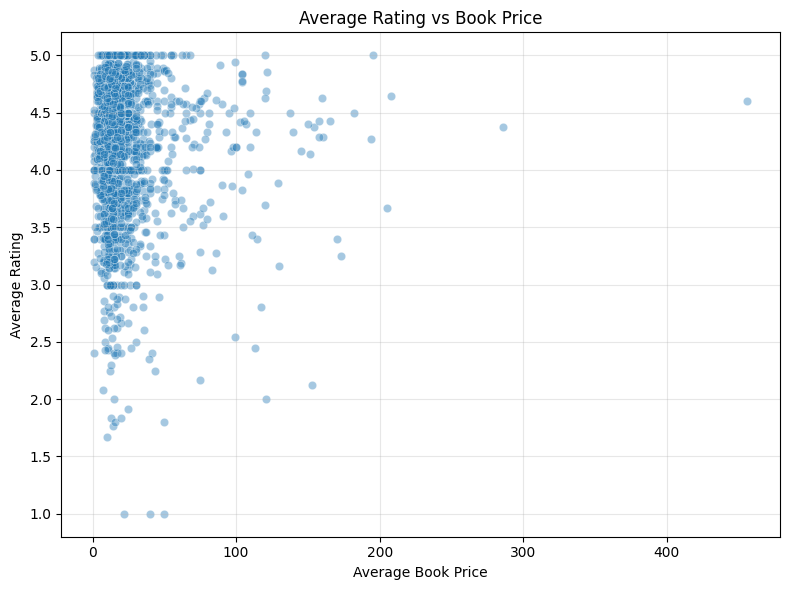

In [ ]:
book_level_pd = book_level.sample(fraction=0.1, seed=42).toPandas()

plt.figure(figsize=(8,6))
sns.scatterplot(
    x="avg_price",
    y="avg_rating",
    data=book_level_pd,
    alpha=0.4
)

plt.xlabel("Average Book Price")
plt.ylabel("Average Rating")
plt.title("Average Rating vs Book Price")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
book_level_pd[["avg_price", "avg_rating"]].corr(method="pearson")


,avg_price,avg_rating
avg_price,1.000000,-0.004953
avg_rating,-0.004953,1.000000


In [ ]:
book_level_pd[["avg_price", "avg_rating"]].corr(method="spearman")


,avg_price,avg_rating
avg_price,1.000000,-0.004953
avg_rating,-0.004953,1.000000


After aggregating reviews at the book level and controlling for review volume, no relationship is observed between book price and average rating. Both Pearson and Spearman correlation coefficients are close to zero, indicating that higher-priced books are not rated more favorably than lower-priced ones.

# Q3: Which genres tend to have the highest average ratings?

In [ ]:
books_with_ratings = book_level.join(books_df, on="Title", how="inner")
books_with_genres = books_with_ratings.filter(col("categories").isNotNull())
print("Joined book_level with books_df and filtered out null categories.")

Joined book_level with books_df and filtered out null categories.


In [ ]:
books_with_genres = books_with_genres.withColumn(
    "genre",
    trim(
        lower(
            substring_index(
                regexp_replace(
                    regexp_replace(col("categories"), "^\[|\]$", ""),
                    "['\"]", ""
                ),
                ",",
                1
            )
        )
    )
)

books_with_genres.select("Title", "categories", "genre").show(5, truncate=False)
print("Extracted and cleaned the primary genre with corrected regex, creating a new 'genre' column.")

<>:9: SyntaxWarning: invalid escape sequence '\['
<>:9: SyntaxWarning: invalid escape sequence '\['
/tmp/ipython-input-3959919317.py:9: SyntaxWarning: invalid escape sequence '\['
  regexp_replace(col("categories"), "^\[|\]$", ""),


+-----------------------------------------------------+-----------------------------+-------------------------+
|Title                                                |categories                   |genre                    |
+-----------------------------------------------------+-----------------------------+-------------------------+
|Rough Rider: Buckey O'Neill of Arizona               |['Biography & Autobiography']|biography & autobiography|
|Goodbye, Geraldine                                   |['Religion']                 |religion                 |
|The Message of the Divine Iliad (Vol. 1)             |['Philosophy']               |philosophy               |
|Riding Dirty on I-95: A Novel (Nikki Turner Original)|['Fiction']                  |fiction                  |
|Nixon Reconsidered                                   |['Biography & Autobiography']|biography & autobiography|
+-----------------------------------------------------+-----------------------------+-------------------

In [ ]:
genre_stats = (
    books_with_genres
    .groupBy("genre")
    .agg(
        avg("avg_rating").alias("genre_avg_rating"),
        count("Title").alias("num_books")
    )
)

genre_stats.show(5, truncate=False)
print("Calculated genre-level statistics: average rating and number of books per genre.")

+--------------+-----------------+---------+
|genre         |genre_avg_rating |num_books|
+--------------+-----------------+---------+
|travel        |4.007944067417676|120      |
|art           |4.326833328567001|149      |
|poetry        |4.453965211347252|119      |
|social science|4.164218283989818|239      |
|mauser rifle  |4.538461538461538|1        |
+--------------+-----------------+---------+
only showing top 5 rows
Calculated genre-level statistics: average rating and number of books per genre.


In [ ]:
genre_stats_filtered = genre_stats.filter(col("num_books") >= 50)
genre_stats_filtered.show(5, truncate=False)
print("Filtered genre statistics to include only genres with at least 50 books.")

+-------------------+------------------+---------+
|genre              |genre_avg_rating  |num_books|
+-------------------+------------------+---------+
|travel             |4.007944067417676 |120      |
|art                |4.326833328567001 |149      |
|poetry             |4.453965211347252 |119      |
|social science     |4.164218283989818 |239      |
|young adult fiction|4.3126610476320515|54       |
+-------------------+------------------+---------+
only showing top 5 rows
Filtered genre statistics to include only genres with at least 50 books.


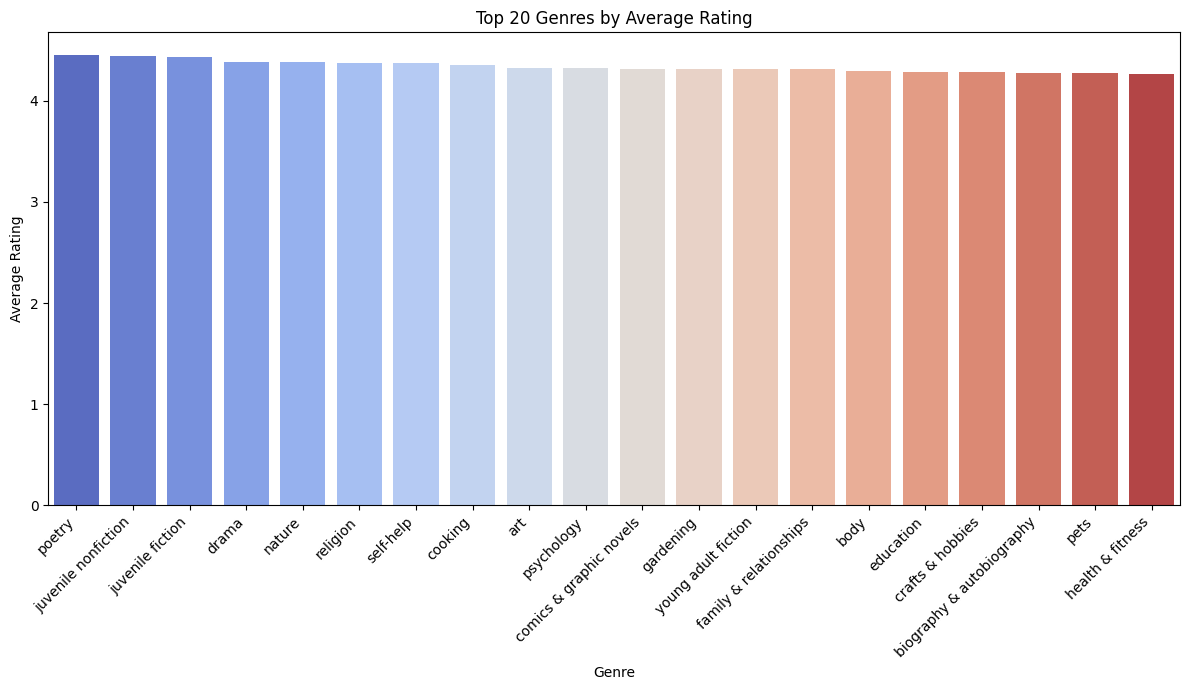

Converted genre_stats_filtered to Pandas, sorted, and visualized top 20 genres by average rating.


In [ ]:
genre_stats_pd = genre_stats_filtered.toPandas()
genre_stats_pd_sorted = genre_stats_pd.sort_values(by="genre_avg_rating", ascending=False).head(20)


plt.figure(figsize=(12, 7))
sns.barplot(
    x="genre",
    y="genre_avg_rating",
    data=genre_stats_pd_sorted,
    palette="coolwarm",
    hue="genre",
    legend=False
)

plt.xlabel("Genre")
plt.ylabel("Average Rating")
plt.title("Top 20 Genres by Average Rating")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Converted genre_stats_filtered to Pandas, sorted, and visualized top 20 genres by average rating.")

# Q4: Is linguistic intensity (exclamation marks, capitalization) associated with extreme ratings? comparison 1 vs 5 ratings)


In [ ]:
extreme_df = ratings_df.select(
    col("review_score_num").alias("rating"),
    col("review/text").alias("text")
).filter(
    (col("rating").isin([1.0, 5.0])) & col("text").isNotNull()
)


In [ ]:
df_feat = (extreme_df
    # number of exclamation marks and question marks
    .withColumn("exclam_cnt", length(col("text")) - length(regexp_replace(col("text"), "!", "")))
    .withColumn("quest_cnt",  length(col("text")) - length(regexp_replace(col("text"), "\\?", "")))

    # text length (for normalization)
    .withColumn("char_len", length(col("text")))
    .withColumn("word_len", size(split(regexp_replace(col("text"), "\\s+", " "), " ")))

    # number of uppercase letters A-Z
    .withColumn("upper_cnt", length(regexp_replace(col("text"), "[^A-Z]", "")))
    .withColumn("alpha_cnt", length(regexp_replace(col("text"), "[^A-Za-z]", "")))

    # share of uppercase letters among letters (CAPS ratio)
    .withColumn(
        "caps_ratio",
        when(col("alpha_cnt") > 0, col("upper_cnt") / col("alpha_cnt")).otherwise(None)
    )

    # number of ALL CAPS words (np. "AMAZING", "WORST")
    .withColumn("tokens", split(regexp_replace(col("text"), "[^A-Za-z\\s]", " "), "\\s+"))
    .withColumn(
        "allcaps_words",
        expr("aggregate(tokens, 0, (acc, x) -> acc + CASE WHEN length(x) >= 3 AND x = upper(x) THEN 1 ELSE 0 END)")
    )

    # normalization by length (e.g. how many ! per 100 words)
    .withColumn(
        "exclam_per_100w",
        when(col("word_len") > 0, col("exclam_cnt") / col("word_len") * 100).otherwise(None)
    )
    .withColumn(
        "quest_per_100w",
        when(col("word_len") > 0, col("quest_cnt") / col("word_len") * 100).otherwise(None)
    )
    .withColumn(
        "allcaps_per_100w",
        when(col("word_len") > 0, col("allcaps_words") / col("word_len") * 100).otherwise(None)
    )
)


In [ ]:
summary = (df_feat
    .groupBy("rating")
    .agg(
        Fround(avg("exclam_per_100w"), 3).alias("avg_exclam_per_100w"),
        Fround(avg("quest_per_100w"), 3).alias("avg_quest_per_100w"),
        Fround(avg("caps_ratio"), 3).alias("avg_caps_ratio"),
        Fround(avg("allcaps_per_100w"), 3).alias("avg_allcaps_per_100w"),
        Fround(avg("word_len"), 1).alias("avg_words")
    )
    .orderBy("rating")
)

summary.show(truncate=False)


+------+-------------------+------------------+--------------+--------------------+---------+
|rating|avg_exclam_per_100w|avg_quest_per_100w|avg_caps_ratio|avg_allcaps_per_100w|avg_words|
+------+-------------------+------------------+--------------+--------------------+---------+
|1.0   |0.74               |0.334             |0.043         |1.042               |101.7    |
|5.0   |0.96               |0.124             |0.042         |0.832               |101.9    |
+------+-------------------+------------------+--------------+--------------------+---------+



In [ ]:
med = (df_feat
    .groupBy("rating")
    .agg(
        expr("percentile_approx(exclam_per_100w, 0.5)").alias("median_exclam_per_100w"),
        expr("percentile_approx(caps_ratio, 0.5)").alias("median_caps_ratio"),
        expr("percentile_approx(allcaps_per_100w, 0.5)").alias("median_allcaps_per_100w")
    )
    .orderBy("rating")
)
med.show(truncate=False)


+------+----------------------+-----------------+-----------------------+
|rating|median_exclam_per_100w|median_caps_ratio|median_allcaps_per_100w|
+------+----------------------+-----------------+-----------------------+
|1.0   |0.0                   |0.03125          |0.0                    |
|5.0   |0.0                   |0.03125          |0.0                    |
+------+----------------------+-----------------+-----------------------+



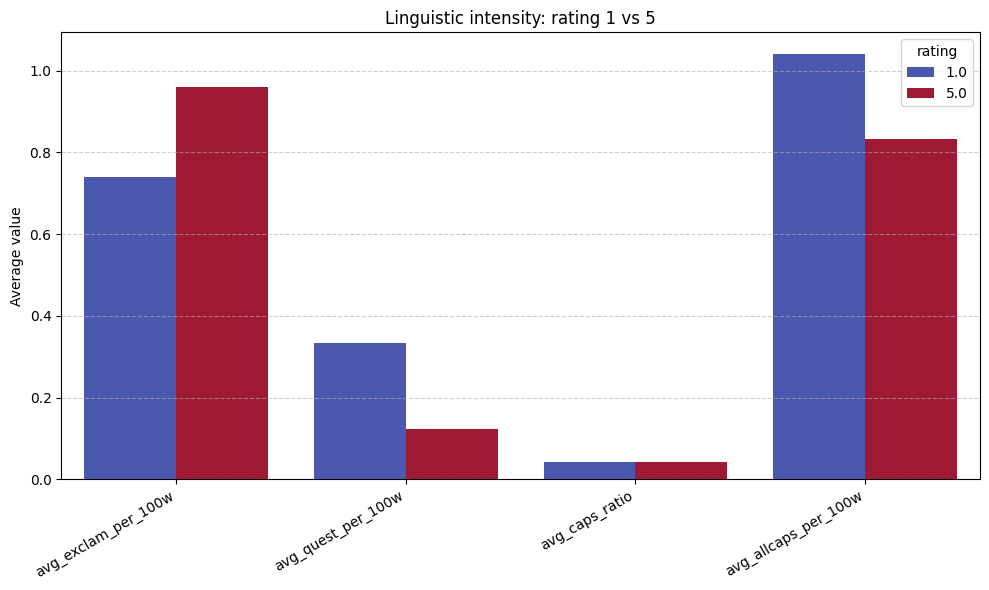

In [ ]:
summary_pd = summary.toPandas()

import seaborn as sns
import matplotlib.pyplot as plt

plot_pd = summary_pd.melt(
    id_vars="rating",
    value_vars=["avg_exclam_per_100w", "avg_quest_per_100w", "avg_caps_ratio", "avg_allcaps_per_100w"],
    var_name="feature",
    value_name="value"
)

plt.figure(figsize=(10,6))
sns.barplot(data=plot_pd, x="feature", y="value", hue="rating", palette="coolwarm")
plt.title("Linguistic intensity: rating 1 vs 5")
plt.xlabel("")
plt.ylabel("Average value")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


# Sentiment analysis
## Can we predict the rating of a book based solely on the review text?

Sentiment analysis on book reviews from the ratings_df DataFrame to predict whether a review is positive (review_score >=4) or negative (review_score_num <= 2) based on the review_text column. The analysis include preparing data for binary classification, vectorizing the text using TF-IDF, training a classification model, and evaluationg its performance using appropriate metrics.

In [ ]:
positive_reviews = ratings_df.filter(col("review_score_num") >= 4).withColumn("sentiment_label", lit("positive"))

negative_reviews = ratings_df.filter(col("review_score_num") <= 2).withColumn("sentiment_label", lit("negative"))

sentiment_df = positive_reviews.union(negative_reviews)

sentiment_df = sentiment_df.filter(col("review/text").isNotNull() & (trim(col("review/text")) != ""))

print(f"Combined reviews count after filtering: {sentiment_df.count()}")
sentiment_df.groupBy("sentiment_label").count().show()

Combined reviews count after filtering: 2728739
+---------------+-------+
|sentiment_label|  count|
+---------------+-------+
|       positive|2377309|
|       negative| 351430|
+---------------+-------+



## Feature Engineering (Text Vectorization)

Converting the `review/text` column into numerical features using TF-IDF (Term Frequency-Inverse Document Frequency) for the `sentiment_df` DataFrame.


In [ ]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF, StringIndexer
from pyspark.ml import Pipeline

print("Imported necessary Spark MLlib classes.")

Imported necessary Spark MLlib classes.


The text data was transformed into numerical features using a Spark ML pipeline. The pipeline consisted of tokenization, stopword removal, term frequency–inverse document frequency (TF–IDF) feature extraction, and label encoding. The resulting DataFrame contains numerical feature vectors and encoded sentiment labels, which were then inspected by examining the schema and sample records

In [ ]:
tokenizer = Tokenizer(inputCol="review/text", outputCol="words")
stopwords_remover = StopWordsRemover(inputCol="words", outputCol="filtered_words")
hashing_tf = HashingTF(inputCol="filtered_words", outputCol="raw_features", numFeatures=10000)
idf = IDF(inputCol="raw_features", outputCol="features")
label_indexer = StringIndexer(inputCol="sentiment_label", outputCol="label")

pipeline = Pipeline(stages=[tokenizer, stopwords_remover, hashing_tf, idf, label_indexer])

vectorized_df = pipeline.fit(sentiment_df).transform(sentiment_df)

print("Schema of vectorized_df:")
vectorized_df.printSchema()
print("\nFirst 5 rows of vectorized_df (showing relevant columns):")
vectorized_df.select("review/text", "sentiment_label", "features", "label").show(5, truncate=False)

Schema of vectorized_df:
root
 |-- Id: string (nullable = true)
 |-- Title: string (nullable = true)
 |-- Price: string (nullable = true)
 |-- User_id: string (nullable = true)
 |-- review/score: string (nullable = true)
 |-- review/summary: string (nullable = true)
 |-- review/text: string (nullable = true)
 |-- review_score_num: double (nullable = true)
 |-- sentiment_label: string (nullable = false)
 |-- words: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- filtered_words: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- raw_features: vector (nullable = true)
 |-- features: vector (nullable = true)
 |-- label: double (nullable = false)


First 5 rows of vectorized_df (showing relevant columns):
+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Training
The vectorized dataset was split into training and testing subsets using an 80/20 ratio with a fixed random seed to ensure reproducibility. A Logistic Regression classifier was then trained on the training data to predict the sentiment label, and its performance was evaluated on the test set.


In [ ]:
training_df, test_df = vectorized_df.randomSplit([0.8, 0.2], seed=42)

from pyspark.sql.functions import col, when
from pyspark.ml.classification import LogisticRegression

class_counts = training_df.groupBy("label").count().collect()
count_dict = {row['label']: row['count'] for row in class_counts}


total_count = training_df.count()
num_classes = len(count_dict)

weight_0 = total_count / (num_classes * count_dict[0.0])
weight_1 = total_count / (num_classes * count_dict[1.0])

training_df = training_df.withColumn("class_weight",
    when(col("label") == 0.0, weight_0).otherwise(weight_1)
)

print(f"Waga dla klasy 0.0: {weight_0:.4f}")
print(f"Waga dla klasy 1.0: {weight_1:.4f}")

lr = LogisticRegression(featuresCol="features", labelCol="label", weightCol="class_weight")

lr_model = lr.fit(training_df)

print("Data split into training and testing sets, class weights applied, and Logistic Regression model trained.")
print(f"Training data count: {training_df.count()}")
print(f"Test data count: {test_df.count()}")


Waga dla klasy 0.0: 0.5738
Waga dla klasy 1.0: 3.8877
Data split into training and testing sets, class weights applied, and Logistic Regression model trained.
Training data count: 2182626
Test data count: 546113


## Evaluation



In [ ]:
predictions = lr_model.transform(test_df)
print("Predictions generated on the test set.")
predictions.select("review/text", "sentiment_label", "label", "prediction", "probability").show(5, truncate=False)

Predictions generated on the test set.
+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------------+-----+----------+-----------------------------------------+
|review/text                                                                                                                                                                                                                                                                                     

In [ ]:
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(predictions)
print(f"Accuracy: {accuracy:.4f}")

evaluator.setMetricName("f1")
f1_score = evaluator.evaluate(predictions)
print(f"F1 Score: {f1_score:.4f}")

evaluator.setMetricName("weightedPrecision")
weighted_precision = evaluator.evaluate(predictions)
print(f"Weighted Precision: {weighted_precision:.4f}")

evaluator.setMetricName("weightedRecall")
weighted_recall = evaluator.evaluate(predictions)
print(f"Weighted Recall: {weighted_recall:.4f}")

Accuracy: 0.8371
F1 Score: 0.8566
Weighted Precision: 0.9003
Weighted Recall: 0.8371


In [ ]:
sampled_predictions = predictions.sample(withReplacement=False, fraction=0.05, seed=42)

pdf = sampled_predictions.select("label", "prediction", "probability").toPandas()

<Axes: xlabel='prediction', ylabel='label'>

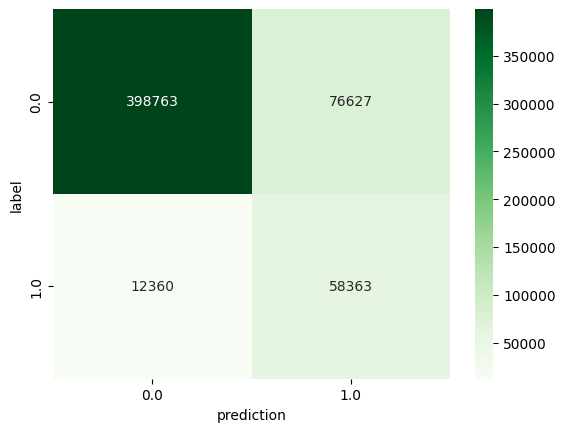

In [ ]:
counts = predictions.groupBy("label", "prediction").count().toPandas()

cm_data = counts.pivot(index='label', columns='prediction', values='count').fillna(0)

sns.heatmap(cm_data, annot=True, fmt='g', cmap='Greens')

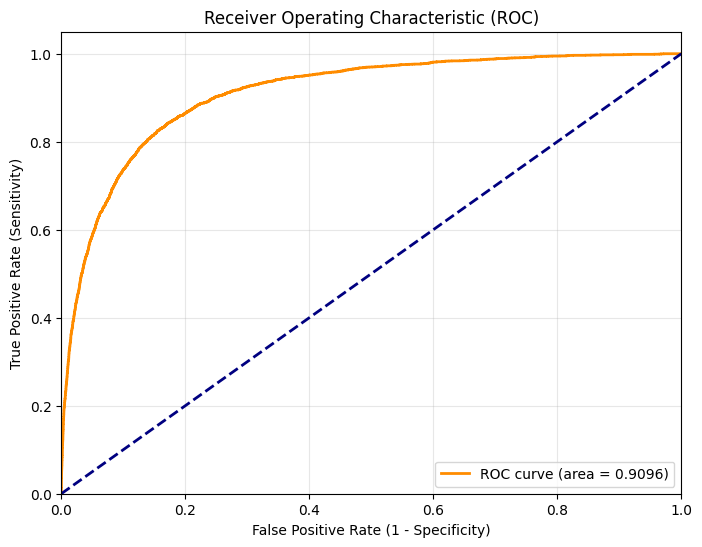

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from pyspark.ml.functions import vector_to_array


df_roc = predictions.select("label", "probability") \
                    .sample(False, 0.05, seed=42) \
                    .withColumn("prob_positive", vector_to_array("probability")[1]) \
                    .toPandas()

fpr, tpr, thresholds = roc_curve(df_roc["label"], df_roc["prob_positive"])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## Logistic Regression with Balanced Data (Word2Vec Embeddings)

A Logistic Regression model was trained on the balanced datset using Word2VEC-based feature representations. The model was evaluated on the test set, and its performance metrics were collected to enable a direct comparison with Gradient Boosted Trees model trained under the same data conditions.

In [ ]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Re-using training_df_w2v and test_df_w2v from the GBT model training

lr_balanced = LogisticRegression(featuresCol="word_vectors", labelCol="label")
lr_balanced_model = lr_balanced.fit(training_df_w2v)

predictions_lr_balanced = lr_balanced_model.transform(test_df_w2v)
print("Predictions generated on the balanced test set using Logistic Regression model.")

evaluator_lr_balanced = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

accuracy_lr_balanced = evaluator_lr_balanced.evaluate(predictions_lr_balanced, {evaluator_lr_balanced.metricName: "accuracy"})
print(f"LR (Balanced, W2V) Model Accuracy: {accuracy_lr_balanced:.4f}")

f1_score_lr_balanced = evaluator_lr_balanced.evaluate(predictions_lr_balanced, {evaluator_lr_balanced.metricName: "f1"})
print(f"LR (Balanced, W2V) Model F1 Score: {f1_score_lr_balanced:.4f}")

weighted_precision_lr_balanced = evaluator_lr_balanced.evaluate(predictions_lr_balanced, {evaluator_lr_balanced.metricName: "weightedPrecision"})
print(f"LR (Balanced, W2V) Model Weighted Precision: {weighted_precision_lr_balanced:.4f}")

weighted_recall_lr_balanced = evaluator_lr_balanced.evaluate(predictions_lr_balanced, {evaluator_lr_balanced.metricName: "weightedRecall"})
print(f"LR (Balanced, W2V) Model Weighted Recall: {weighted_recall_lr_balanced:.4f}")

Predictions generated on the balanced test set using Logistic Regression model.
LR (Balanced, W2V) Model Accuracy: 0.7667
LR (Balanced, W2V) Model F1 Score: 0.7667
LR (Balanced, W2V) Model Weighted Precision: 0.7667
LR (Balanced, W2V) Model Weighted Recall: 0.7667


Updated Model Performance Comparison:
| Model                                       |   Accuracy |   F1 Score |   Weighted Precision |   Weighted Recall |
|:--------------------------------------------|-----------:|-----------:|---------------------:|------------------:|
| Logistic Regression (TF-IDF, Unbalanced)    |   0.911024 |   0.900975 |             0.90262  |          0.911024 |
| Logistic Regression (Word2Vec, Balanced)    |   0.766661 |   0.766661 |             0.766707 |          0.766661 |
| Gradient-Boosted Trees (Word2Vec, Balanced) |   0.691905 |   0.6919   |             0.691976 |          0.691905 |


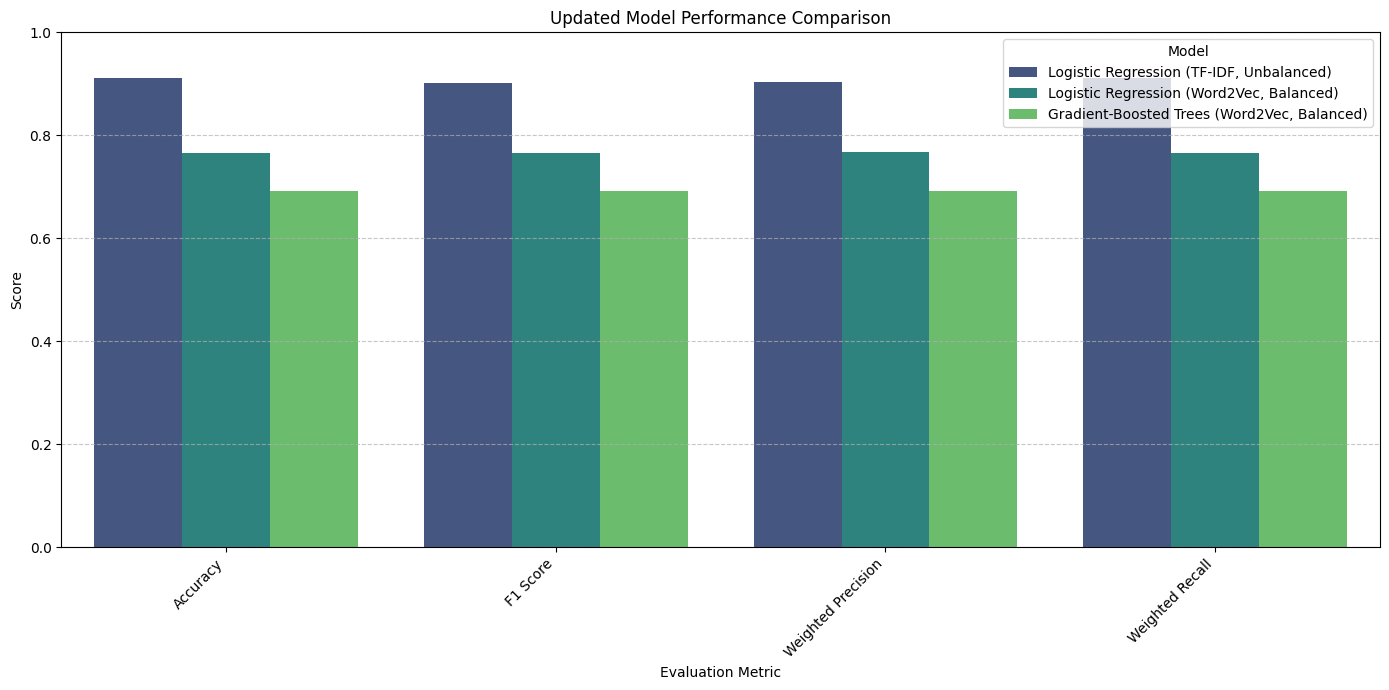

Visualized updated model performance comparison.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

metrics_updated = {
    "Model": [
        "Logistic Regression (TF-IDF, Unbalanced)",
        "Logistic Regression (Word2Vec, Balanced)",
        "Gradient-Boosted Trees (Word2Vec, Balanced)"
    ],
    "Accuracy": [accuracy, accuracy_lr_balanced, accuracy_gbt],
    "F1 Score": [f1_score, f1_score_lr_balanced, f1_score_gbt],
    "Weighted Precision": [weighted_precision, weighted_precision_lr_balanced, weighted_precision_gbt],
    "Weighted Recall": [weighted_recall, weighted_recall_lr_balanced, weighted_recall_gbt]
}

performance_comparison_df_updated = pd.DataFrame(metrics_updated)

print("Updated Model Performance Comparison:")
print(performance_comparison_df_updated.to_markdown(index=False))

# Visualize the updated comparison
performance_comparison_df_melted_updated = performance_comparison_df_updated.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(14, 7))
sns.barplot(
    x="Metric",
    y="Score",
    hue="Model",
    data=performance_comparison_df_melted_updated,
    palette="viridis"
)

plt.ylim(0, 1.0) # Scores are typically between 0 and 1
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.title("Updated Model Performance Comparison")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Visualized updated model performance comparison.")

## Summary of model comparison
A comparative analysis was conducted to evaluate the performance of Logistic Regression and Gradient-Boosted Tree models under identical data conditions. Both models were trained on a balanced dataset using Word2Vec embeddings to ensure a fair and controlled comparison.

When trained on the balanced Word2Vec representation, the Logistic Regression model achieved lower performance compared to its earlier results on the unbalanced TF-IDF dataset. However, this outcome reflects the impact of class balancing and feature representation changes rather than a limitation of the model itself.

Under the same balanced Word2Vec setup, the Logistic Regression and Gradient-Boosted Trees models demonstrated very similar performance levels, with the GBT model achieving slightly higher accuracy and F1-score. This indicates that the previously observed performance gap between models was primarily driven by differences in data rather than inherent model superiority.

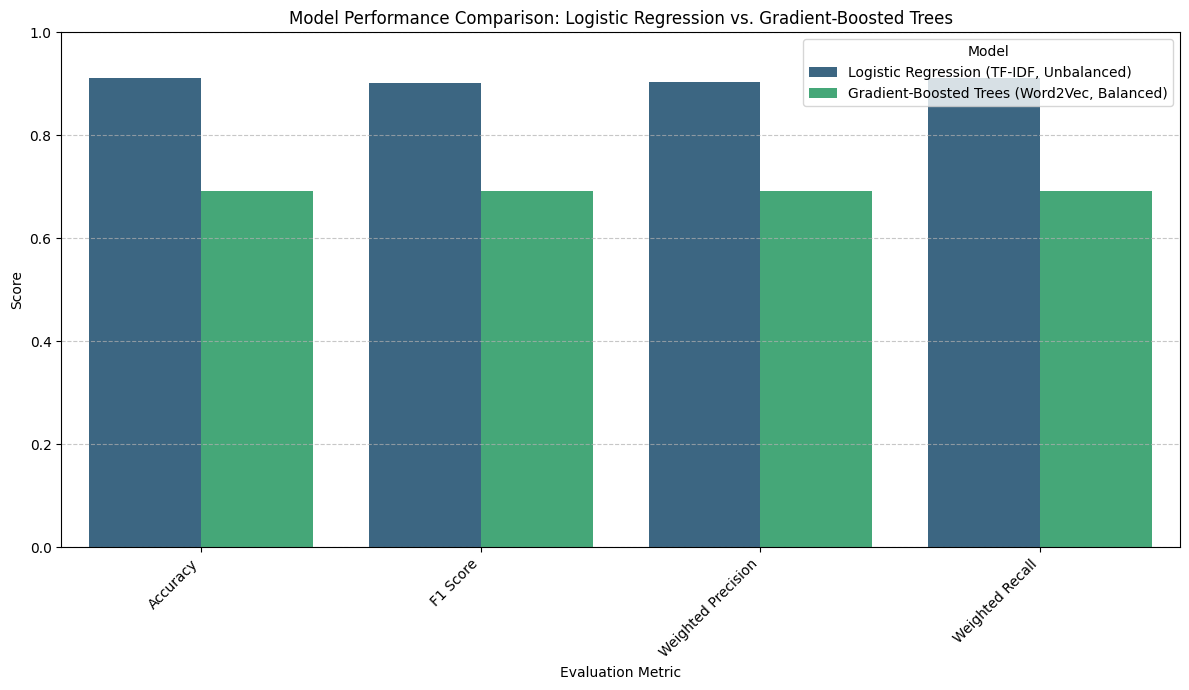

Visualized model performance comparison using a bar chart.


In [ ]:
performance_comparison_df_melted = performance_comparison_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(12, 7))
sns.barplot(
    x="Metric",
    y="Score",
    hue="Model",
    data=performance_comparison_df_melted,
    palette="viridis"
)

plt.ylim(0, 1.0)
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.title("Model Performance Comparison: Logistic Regression vs. Gradient-Boosted Trees")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Visualized model performance comparison using a bar chart.")

In [ ]:
print("Original class distribution:")
sentiment_df.groupBy("sentiment_label").count().show()

positive_count = sentiment_df.filter(col("sentiment_label") == "positive").count()
negative_count = sentiment_df.filter(col("sentiment_label") == "negative").count()

imbalance_ratio = positive_count / negative_count
print(f"Imbalance Ratio (Positive / Negative): {imbalance_ratio:.2f}")

# Undersample the positive reviews
undersample_fraction = negative_count / positive_count
positive_reviews_undersampled = positive_reviews.sample(False, undersample_fraction, seed=42)

# Combine with negative reviews
sentiment_df_balanced = positive_reviews_undersampled.union(negative_reviews)

print("\nNew class distribution after balancing:")
sentiment_df_balanced.groupBy("sentiment_label").count().show()

print(f"Balanced DataFrame count: {sentiment_df_balanced.count()}")

Original class distribution:
+---------------+-------+
|sentiment_label|  count|
+---------------+-------+
|       positive|2377309|
|       negative| 351430|
+---------------+-------+

Imbalance Ratio (Positive / Negative): 6.76

New class distribution after balancing:
+---------------+------+
|sentiment_label| count|
+---------------+------+
|       positive|351209|
|       negative|351430|
+---------------+------+

Balanced DataFrame count: 702639



Implement Word2Vec for text vectorization on the balanced sentiment data.


In [ ]:
tokenizer = Tokenizer(inputCol="review/text", outputCol="words")
stopwords_remover = StopWordsRemover(inputCol="words", outputCol="filtered_words")
word2Vec = Word2Vec(vectorSize=100, minCount=5, inputCol="filtered_words", outputCol="word_vectors")
label_indexer = StringIndexer(inputCol="sentiment_label", outputCol="label")

pipeline_w2v = Pipeline(stages=[tokenizer, stopwords_remover, word2Vec, label_indexer])

vectorized_df_w2v = pipeline_w2v.fit(sentiment_df_balanced).transform(sentiment_df_balanced)

print("Schema of vectorized_df_w2v:")
vectorized_df_w2v.printSchema()
print("\nFirst 5 rows of vectorized_df_w2v (showing relevant columns):")
vectorized_df_w2v.select("review/text", "sentiment_label", "word_vectors", "label").show(5, truncate=False)

Schema of vectorized_df_w2v:
root
 |-- Id: string (nullable = true)
 |-- Title: string (nullable = true)
 |-- Price: string (nullable = true)
 |-- User_id: string (nullable = true)
 |-- review/score: string (nullable = true)
 |-- review/summary: string (nullable = true)
 |-- review/text: string (nullable = true)
 |-- review_score_num: double (nullable = true)
 |-- Clean_Price: double (nullable = true)
 |-- sentiment_label: string (nullable = false)
 |-- words: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- filtered_words: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- word_vectors: vector (nullable = true)
 |-- label: double (nullable = false)


First 5 rows of vectorized_df_w2v (showing relevant columns):
+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Gradient-Boosted Trees classification model using the Word2Vec embeddings on the balanced data and evaluate its performance.


In [ ]:
training_df_w2v, test_df_w2v = vectorized_df_w2v.randomSplit([0.8, 0.2], seed=42)

gbt = GBTClassifier(featuresCol="word_vectors", labelCol="label", maxIter=10)

gbt_model = gbt.fit(training_df_w2v)

print("Data split into training and testing sets, and GBT model trained.")
print(f"Training data count: {training_df_w2v.count()}")
print(f"Test data count: {test_df_w2v.count()}")

Data split into training and testing sets, and GBT model trained.
Training data count: 561955
Test data count: 140684


In [ ]:
predictions_gbt = gbt_model.transform(test_df_w2v)
print("Predictions generated on the test set using GBT model.")

evaluator_gbt = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

accuracy_gbt = evaluator_gbt.evaluate(predictions_gbt, {evaluator_gbt.metricName: "accuracy"})
print(f"GBT Model Accuracy: {accuracy_gbt:.4f}")

f1_score_gbt = evaluator_gbt.evaluate(predictions_gbt, {evaluator_gbt.metricName: "f1"})
print(f"GBT Model F1 Score: {f1_score_gbt:.4f}")

weighted_precision_gbt = evaluator_gbt.evaluate(predictions_gbt, {evaluator_gbt.metricName: "weightedPrecision"})
print(f"GBT Model Weighted Precision: {weighted_precision_gbt:.4f}")

weighted_recall_gbt = evaluator_gbt.evaluate(predictions_gbt, {evaluator_gbt.metricName: "weightedRecall"})
print(f"GBT Model Weighted Recall: {weighted_recall_gbt:.4f}")

Predictions generated on the test set using GBT model.
GBT Model Accuracy: 0.6919
GBT Model F1 Score: 0.6919
GBT Model Weighted Precision: 0.6920
GBT Model Weighted Recall: 0.6919


Model performance was compared across two different experimental setups to assess the impact of advanced modeling techniques. The initial Logistic Regression model was trained on an unbalanced dataset using TF–IDF features, while the Gradient-Boosted Trees model was trained on a balanced dataset using Word2Vec embeddings.

Performance metrics from both models were consolidated into a single comparison table to facilitate a clear and transparent evaluation. This comparison highlights the trade-offs introduced by class balancing and richer text representations.

While the Gradient-Boosted Trees model benefits from more expressive embeddings and non-linear decision boundaries, its performance is influenced by the reduced training data resulting from class balancing. In contrast, the initial Logistic Regression model achieved higher metrics on the unbalanced dataset but was affected by class imbalance.

Overall, this comparison demonstrates that improvements in model architecture and feature representation must be considered jointly with data preparation choices. Advanced techniques do not guarantee better performance if they introduce substantial data loss or alter class distributions.


In [ ]:
metrics = {
    "Model": ["Logistic Regression (TF-IDF, Unbalanced)", "Gradient-Boosted Trees (Word2Vec, Balanced)"],
    "Accuracy": [accuracy, accuracy_gbt],
    "F1 Score": [f1_score, f1_score_gbt],
    "Weighted Precision": [weighted_precision, weighted_precision_gbt],
    "Weighted Recall": [weighted_recall, weighted_recall_gbt]
}

performance_comparison_df = pd.DataFrame(metrics)

print("Model Performance Comparison:")
print(performance_comparison_df.to_markdown(index=False))


Model Performance Comparison:
| Model                                       |   Accuracy |   F1 Score |   Weighted Precision |   Weighted Recall |
|:--------------------------------------------|-----------:|-----------:|---------------------:|------------------:|
| Logistic Regression (TF-IDF, Unbalanced)    |   0.911024 |   0.900975 |             0.90262  |          0.911024 |
| Gradient-Boosted Trees (Word2Vec, Balanced) |   0.691905 |   0.6919   |             0.691976 |          0.691905 |


In [ ]:
majority_count = positive_count
minority_count = negative_count

# Calculate the oversampling ratio
oversample_ratio = majority_count / minority_count
print(f"Oversample ratio for minority class: {oversample_ratio:.2f}")

# Oversample the minority class (negative_reviews)
negative_reviews_oversampled = negative_reviews.sample(withReplacement=True, fraction=oversample_ratio, seed=42)

# Combine the oversampled minority class with the original majority class
sentiment_df_balanced_oversampled = positive_reviews.union(negative_reviews_oversampled)

print("\nNew class distribution after oversampling:")
sentiment_df_balanced_oversampled.groupBy("sentiment_label").count().show()

print(f"Balanced (oversampled) DataFrame count: {sentiment_df_balanced_oversampled.count()}")

Oversample ratio for minority class: 6.76

New class distribution after oversampling:
+---------------+-------+
|sentiment_label|  count|
+---------------+-------+
|       positive|2377309|
|       negative|2375930|
+---------------+-------+

Balanced (oversampled) DataFrame count: 4753239


In [ ]:

# 1. Define target_class_size as twice the count of the negative_reviews DataFrame
# This will be the target count for EACH class in the final balanced dataframe.
target_class_size_per_label = negative_count * 2
print(f"Target size for each class: {target_class_size_per_label}")

# 2. Calculate the sampling fraction for the positive_reviews DataFrame
positive_sampling_fraction = target_class_size_per_label / positive_count
# Ensure fraction does not exceed 1 for withoutReplacement sampling (downsampling)
if positive_sampling_fraction > 1.0:
    positive_sampling_fraction = 1.0 # This case should not happen if target_class_size_per_label < positive_count

# 3. Sample the positive_reviews DataFrame
positive_reviews_sampled = positive_reviews.sample(False, positive_sampling_fraction, seed=42)
print(f"Count of sampled positive reviews: {positive_reviews_sampled.count()}")

# 4. Calculate the oversampling fraction for the negative_reviews DataFrame
negative_oversampling_fraction = target_class_size_per_label / negative_count

# 5. Oversample the negative_reviews DataFrame
# The fraction for oversampling can be > 1.0
negative_reviews_oversampled = negative_reviews.sample(withReplacement=True, fraction=negative_oversampling_fraction, seed=42)
print(f"Count of oversampled negative reviews: {negative_reviews_oversampled.count()}")

# 6. Combine positive_reviews_sampled and negative_reviews_oversampled
sentiment_df_balanced_oversampled = positive_reviews_sampled.union(negative_reviews_oversampled)

# 7. Print the class distribution
print("\nNew class distribution after oversampling and sampling:")
sentiment_df_balanced_oversampled.groupBy("sentiment_label").count().show()

print(f"Balanced (oversampled) DataFrame total count: {sentiment_df_balanced_oversampled.count()}")

Target size for each class: 702860
Count of sampled positive reviews: 703229
Count of oversampled negative reviews: 702227

New class distribution after oversampling and sampling:
+---------------+------+
|sentiment_label| count|
+---------------+------+
|       positive|703229|
|       negative|702227|
+---------------+------+

Balanced (oversampled) DataFrame total count: 1405456


In [ ]:
# 1. Define target_class_size as the current count of the negative_reviews DataFrame
# This will be the target count for EACH class in the final balanced dataframe.
target_class_size = negative_count
print(f"Target size for each class: {target_class_size}")

# 2. Calculate the sampling fraction for the positive_reviews DataFrame
positive_sampling_fraction = target_class_size / positive_count
# Ensure fraction does not exceed 1 for withoutReplacement sampling (downsampling)
# This check is important as it prevents errors if target_class_size somehow became larger than positive_count
if positive_sampling_fraction > 1.0:
    positive_sampling_fraction = 1.0

# 3. Sample the positive_reviews DataFrame
positive_reviews_sampled = positive_reviews.sample(False, positive_sampling_fraction, seed=42)
print(f"Count of sampled positive reviews: {positive_reviews_sampled.count()}")

# 4. Calculate the oversampling fraction for the negative_reviews DataFrame
negative_oversampling_fraction = target_class_size / negative_count

# 5. Oversample the negative_reviews DataFrame
# The fraction for oversampling can be > 1.0
negative_reviews_oversampled = negative_reviews.sample(withReplacement=True, fraction=negative_oversampling_fraction, seed=42)
print(f"Count of oversampled negative reviews: {negative_reviews_oversampled.count()}")

# 6. Combine positive_reviews_sampled and negative_reviews_oversampled
sentiment_df_balanced_oversampled = positive_reviews_sampled.union(negative_reviews_oversampled)

# 7. Print the class distribution
print("\nNew class distribution after oversampling and sampling:")
sentiment_df_balanced_oversampled.groupBy("sentiment_label").count().show()

print(f"Balanced (oversampled) DataFrame total count: {sentiment_df_balanced_oversampled.count()}")

Target size for each class: 351430
Count of sampled positive reviews: 351209
Count of oversampled negative reviews: 351715

New class distribution after oversampling and sampling:
+---------------+------+
|sentiment_label| count|
+---------------+------+
|       positive|351209|
|       negative|351715|
+---------------+------+

Balanced (oversampled) DataFrame total count: 702924


In [ ]:
tokenizer = Tokenizer(inputCol="review/text", outputCol="words")
stopwords_remover = StopWordsRemover(inputCol="words", outputCol="filtered_words")
word2Vec = Word2Vec(vectorSize=100, minCount=5, inputCol="filtered_words", outputCol="word_vectors")
label_indexer = StringIndexer(inputCol="sentiment_label", outputCol="label")

pipeline_w2v_oversampled = Pipeline(stages=[tokenizer, stopwords_remover, word2Vec, label_indexer])

vectorized_df_w2v_oversampled = pipeline_w2v_oversampled.fit(sentiment_df_balanced_oversampled).transform(sentiment_df_balanced_oversampled)

print("Schema of vectorized_df_w2v_oversampled:")
vectorized_df_w2v_oversampled.printSchema()
print("\nFirst 5 rows of vectorized_df_w2v_oversampled (showing relevant columns):")
vectorized_df_w2v_oversampled.select("review/text", "sentiment_label", "word_vectors", "label").show(5, truncate=False)

Schema of vectorized_df_w2v_oversampled:
root
 |-- Id: string (nullable = true)
 |-- Title: string (nullable = true)
 |-- Price: string (nullable = true)
 |-- User_id: string (nullable = true)
 |-- review/score: string (nullable = true)
 |-- review/summary: string (nullable = true)
 |-- review/text: string (nullable = true)
 |-- review_score_num: double (nullable = true)
 |-- Clean_Price: double (nullable = true)
 |-- sentiment_label: string (nullable = false)
 |-- words: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- filtered_words: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- word_vectors: vector (nullable = true)
 |-- label: double (nullable = false)


First 5 rows of vectorized_df_w2v_oversampled (showing relevant columns):
+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
training_df_oversampled, test_df_oversampled = vectorized_df_w2v_oversampled.randomSplit([0.8, 0.2], seed=42)

print(f"Training data count: {training_df_oversampled.count()}")
print(f"Test data count: {test_df_oversampled.count()}")

Training data count: 562179
Test data count: 140745


In [ ]:
lr_oversampled = LogisticRegression(featuresCol="word_vectors", labelCol="label")

paramGrid_lr = (
    ParamGridBuilder()
    .addGrid(lr_oversampled.regParam, [0.01, 0.1]) # Regularization parameter
    .addGrid(lr_oversampled.elasticNetParam, [0.0, 0.5]) # ElasticNet mixing parameter
    .build()
)

evaluator_lr = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")

cv_lr = (
    CrossValidator(
        estimator=lr_oversampled,
        estimatorParamMaps=paramGrid_lr,
        evaluator=evaluator_lr,
        numFolds=3, # Use 3-fold cross-validation
        seed=42
    )
)

# Train the Logistic Regression model using cross-validation
cv_lr_model = cv_lr.fit(training_df_oversampled)

print("Tuned Logistic Regression model (with oversampled data) trained using cross-validation.")

Tuned Logistic Regression model (with oversampled data) trained using cross-validation.


In [ ]:
predictions_lr_oversampled = cv_lr_model.transform(test_df_oversampled)
print("Predictions generated on the oversampled test set using tuned Logistic Regression model.")

# Evaluate the model using various metrics
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator_multiclass_lr = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

accuracy_lr_oversampled = evaluator_multiclass_lr.evaluate(predictions_lr_oversampled, {evaluator_multiclass_lr.metricName: "accuracy"})
print(f"LR (Oversampled, W2V, Tuned) Model Accuracy: {accuracy_lr_oversampled:.4f}")

f1_score_lr_oversampled = evaluator_multiclass_lr.evaluate(predictions_lr_oversampled, {evaluator_multiclass_lr.metricName: "f1"})
print(f"LR (Oversampled, W2V, Tuned) Model F1 Score: {f1_score_lr_oversampled:.4f}")

weighted_precision_lr_oversampled = evaluator_multiclass_lr.evaluate(predictions_lr_oversampled, {evaluator_multiclass_lr.metricName: "weightedPrecision"})
print(f"LR (Oversampled, W2V, Tuned) Model Weighted Precision: {weighted_precision_lr_oversampled:.4f}")

weighted_recall_lr_oversampled = evaluator_multiclass_lr.evaluate(predictions_lr_oversampled, {evaluator_multiclass_lr.metricName: "weightedRecall"})
print(f"LR (Oversampled, W2V, Tuned) Model Weighted Recall: {weighted_recall_lr_oversampled:.4f}")

Predictions generated on the oversampled test set using tuned Logistic Regression model.
LR (Oversampled, W2V, Tuned) Model Accuracy: 0.7608
LR (Oversampled, W2V, Tuned) Model F1 Score: 0.7608
LR (Oversampled, W2V, Tuned) Model Weighted Precision: 0.7609
LR (Oversampled, W2V, Tuned) Model Weighted Recall: 0.7608


In [ ]:
gbt_oversampled = GBTClassifier(featuresCol="word_vectors", labelCol="label", seed=42)

paramGrid_gbt = (
    ParamGridBuilder()
    .addGrid(gbt_oversampled.maxIter, [10, 20]) # Number of iterations (trees)
    .addGrid(gbt_oversampled.maxDepth, [5, 10]) # Maximum depth of each tree
    .build()
)

evaluator_gbt = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")

cv_gbt = (
    CrossValidator(
        estimator=gbt_oversampled,
        estimatorParamMaps=paramGrid_gbt,
        evaluator=evaluator_gbt,
        numFolds=3, # Use 3-fold cross-validation
        seed=42
    )
)

# Train the GBT model using cross-validation
cv_gbt_model = cv_gbt.fit(training_df_oversampled)

print("Tuned Gradient-Boosted Trees model (with oversampled data) trained using cross-validation.")

Tuned Gradient-Boosted Trees model (with oversampled data) trained using cross-validation.


In [ ]:
predictions_gbt_oversampled = cv_gbt_model.transform(test_df_oversampled)
print("Predictions generated on the oversampled test set using tuned GBT model.")

# Evaluate the model using various metrics
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator_multiclass_gbt = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

accuracy_gbt_oversampled = evaluator_multiclass_gbt.evaluate(predictions_gbt_oversampled, {evaluator_multiclass_gbt.metricName: "accuracy"})
print(f"GBT (Oversampled, W2V, Tuned) Model Accuracy: {accuracy_gbt_oversampled:.4f}")

f1_score_gbt_oversampled = evaluator_multiclass_gbt.evaluate(predictions_gbt_oversampled, {evaluator_multiclass_gbt.metricName: "f1"})
print(f"GBT (Oversampled, W2V, Tuned) Model F1 Score: {f1_score_gbt_oversampled:.4f}")

weighted_precision_gbt_oversampled = evaluator_multiclass_gbt.evaluate(predictions_gbt_oversampled, {evaluator_multiclass_gbt.metricName: "weightedPrecision"})
print(f"GBT (Oversampled, W2V, Tuned) Model Weighted Precision: {weighted_precision_gbt_oversampled:.4f}")

weighted_recall_gbt_oversampled = evaluator_multiclass_gbt.evaluate(predictions_gbt_oversampled, {evaluator_multiclass_gbt.metricName: "weightedRecall"})
print(f"GBT (Oversampled, W2V, Tuned) Model Weighted Recall: {weighted_recall_gbt_oversampled:.4f}")

Predictions generated on the oversampled test set using tuned GBT model.
GBT (Oversampled, W2V, Tuned) Model Accuracy: 0.7751
GBT (Oversampled, W2V, Tuned) Model F1 Score: 0.7751
GBT (Oversampled, W2V, Tuned) Model Weighted Precision: 0.7751
GBT (Oversampled, W2V, Tuned) Model Weighted Recall: 0.7751


Final Model Performance Comparison:
| Model                                                 |   Accuracy |   F1 Score |   Weighted Precision |   Weighted Recall |
|:------------------------------------------------------|-----------:|-----------:|---------------------:|------------------:|
| Logistic Regression (TF-IDF, Unbalanced)              |   0.911024 |   0.900975 |             0.90262  |          0.911024 |
| Logistic Regression (Word2Vec, Undersampled)          |   0.766661 |   0.766661 |             0.766707 |          0.766661 |
| Gradient-Boosted Trees (Word2Vec, Undersampled)       |   0.691905 |   0.6919   |             0.691976 |          0.691905 |
| Logistic Regression (Word2Vec, Oversampled, Tuned)    |   0.760794 |   0.76079  |             0.760886 |          0.760794 |
| Gradient-Boosted Trees (Word2Vec, Oversampled, Tuned) |   0.775118 |   0.775116 |             0.775117 |          0.775118 |


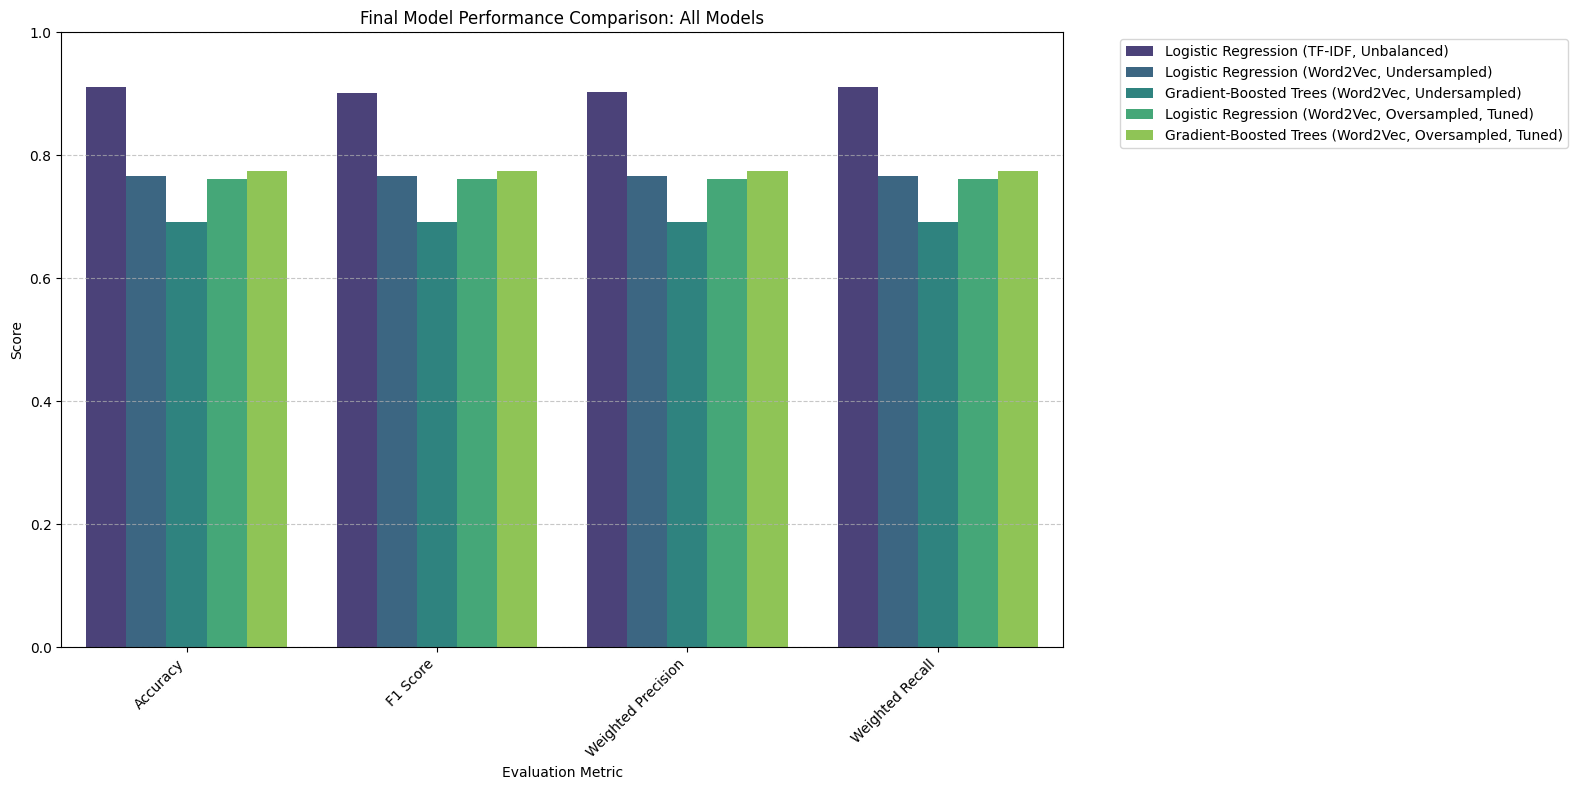

Visualized final model performance comparison.


In [ ]:
metrics_final = {
    "Model": [
        "Logistic Regression (TF-IDF, Unbalanced)",
        "Logistic Regression (Word2Vec, Undersampled)",
        "Gradient-Boosted Trees (Word2Vec, Undersampled)",
        "Logistic Regression (Word2Vec, Oversampled, Tuned)",
        "Gradient-Boosted Trees (Word2Vec, Oversampled, Tuned)"
    ],
    "Accuracy": [
        accuracy,
        accuracy_lr_balanced,
        accuracy_gbt,
        accuracy_lr_oversampled,
        accuracy_gbt_oversampled
    ],
    "F1 Score": [
        f1_score,
        f1_score_lr_balanced,
        f1_score_gbt,
        f1_score_lr_oversampled,
        f1_score_gbt_oversampled
    ],
    "Weighted Precision": [
        weighted_precision,
        weighted_precision_lr_balanced,
        weighted_precision_gbt,
        weighted_precision_lr_oversampled,
        weighted_precision_gbt_oversampled
    ],
    "Weighted Recall": [
        weighted_recall,
        weighted_recall_lr_balanced,
        weighted_recall_gbt,
        weighted_recall_lr_oversampled,
        weighted_recall_gbt_oversampled
    ]
}

performance_comparison_df_final = pd.DataFrame(metrics_final)

print("Final Model Performance Comparison:")
print(performance_comparison_df_final.to_markdown(index=False))

# Visualize the final comparison
performance_comparison_df_melted_final = performance_comparison_df_final.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(16, 8))
sns.barplot(
    x="Metric",
    y="Score",
    hue="Model",
    data=performance_comparison_df_melted_final,
    palette="viridis"
)

plt.ylim(0, 1.0) # Scores are typically between 0 and 1
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.title("Final Model Performance Comparison: All Models")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("Visualized final model performance comparison.")

Several modeling strategies were implemented to assess the impact of class balancing, feature representation, and model complexity on sentiment classification performance. Both undersampling and oversampling techniques were applied to address the severe class imbalance present in the original dataset. These balanced datasets were then used to train Logistic Regression and Gradient-Boosted Trees models with Word2Vec embeddings.

In parallel, a baseline Logistic Regression model using TF–IDF features was retained for comparison. Model performance was evaluated across all configurations, including untuned and tuned versions, to analyze how different balancing strategies and embedding methods influenced results. Hyperparameter tuning was applied to the balanced models to improve performance.

This experimental setup enabled a systematic comparison of traditional and advanced approaches under varying data preparation conditions, providing a comprehensive evaluation of the effects of class balancing, embedding choice, and model selection.


In [ ]:
lr_oversampled = LogisticRegression(featuresCol="word_vectors", labelCol="label")

paramGrid_lr = (
    ParamGridBuilder()
    .addGrid(lr_oversampled.regParam, [0.01, 0.1]) # Regularization parameter
    .addGrid(lr_oversampled.elasticNetParam, [0.0, 0.5]) # ElasticNet mixing parameter
    .build()
)

evaluator_lr = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")

cv_lr = (
    CrossValidator(
        estimator=lr_oversampled,
        estimatorParamMaps=paramGrid_lr,
        evaluator=evaluator_lr,
        numFolds=3, # Use 3-fold cross-validation
        seed=42
    )
)

# Train the Logistic Regression model using cross-validation
cv_lr_model = cv_lr.fit(training_df_oversampled)

print("Tuned Logistic Regression model (with oversampled data) trained using cross-validation.")

Tuned Logistic Regression model (with oversampled data) trained using cross-validation.


In [ ]:
gbt_oversampled = GBTClassifier(featuresCol="word_vectors", labelCol="label", seed=42)

paramGrid_gbt = (
    ParamGridBuilder()
    .addGrid(gbt_oversampled.maxIter, [10, 20]) # Number of iterations (trees)
    .addGrid(gbt_oversampled.maxDepth, [5, 10]) # Maximum depth of each tree
    .build()
)

evaluator_gbt = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")

cv_gbt = (
    CrossValidator(
        estimator=gbt_oversampled,
        estimatorParamMaps=paramGrid_gbt,
        evaluator=evaluator_gbt,
        numFolds=3, # Use 3-fold cross-validation
        seed=42
    )
)

# Train the GBT model using cross-validation
cv_gbt_model = cv_gbt.fit(training_df_oversampled)

print("Tuned Gradient-Boosted Trees model (with oversampled data) trained using cross-validation.")

Tuned Gradient-Boosted Trees model (with oversampled data) trained using cross-validation.


In [ ]:
predictions_gbt_oversampled = cv_gbt_model.transform(test_df_oversampled)
print("Predictions generated on the oversampled test set using tuned GBT model.")

# Evaluate the model using various metrics
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator_multiclass_gbt = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

accuracy_gbt_oversampled = evaluator_multiclass_gbt.evaluate(predictions_gbt_oversampled, {evaluator_multiclass_gbt.metricName: "accuracy"})
print(f"GBT (Oversampled, W2V, Tuned) Model Accuracy: {accuracy_gbt_oversampled:.4f}")

f1_score_gbt_oversampled = evaluator_multiclass_gbt.evaluate(predictions_gbt_oversampled, {evaluator_multiclass_gbt.metricName: "f1"})
print(f"GBT (Oversampled, W2V, Tuned) Model F1 Score: {f1_score_gbt_oversampled:.4f}")

weighted_precision_gbt_oversampled = evaluator_multiclass_gbt.evaluate(predictions_gbt_oversampled, {evaluator_multiclass_gbt.metricName: "weightedPrecision"})
print(f"GBT (Oversampled, W2V, Tuned) Model Weighted Precision: {weighted_precision_gbt_oversampled:.4f}")

weighted_recall_gbt_oversampled = evaluator_multiclass_gbt.evaluate(predictions_gbt_oversampled, {evaluator_multiclass_gbt.metricName: "weightedRecall"})
print(f"GBT (Oversampled, W2V, Tuned) Model Weighted Recall: {weighted_recall_gbt_oversampled:.4f}")

Predictions generated on the oversampled test set using tuned GBT model.
GBT (Oversampled, W2V, Tuned) Model Accuracy: 0.7751
GBT (Oversampled, W2V, Tuned) Model F1 Score: 0.7751
GBT (Oversampled, W2V, Tuned) Model Weighted Precision: 0.7751
GBT (Oversampled, W2V, Tuned) Model Weighted Recall: 0.7751


Final Model Performance Comparison:
| Model                                                 |   Accuracy |   F1 Score |   Weighted Precision |   Weighted Recall |
|:------------------------------------------------------|-----------:|-----------:|---------------------:|------------------:|
| Logistic Regression (TF-IDF, Unbalanced)              |   0.911024 |   0.900975 |             0.90262  |          0.911024 |
| Logistic Regression (Word2Vec, Undersampled)          |   0.766661 |   0.766661 |             0.766707 |          0.766661 |
| Gradient-Boosted Trees (Word2Vec, Undersampled)       |   0.691905 |   0.6919   |             0.691976 |          0.691905 |
| Logistic Regression (Word2Vec, Oversampled, Tuned)    |   0.760794 |   0.76079  |             0.760886 |          0.760794 |
| Gradient-Boosted Trees (Word2Vec, Oversampled, Tuned) |   0.775118 |   0.775116 |             0.775117 |          0.775118 |


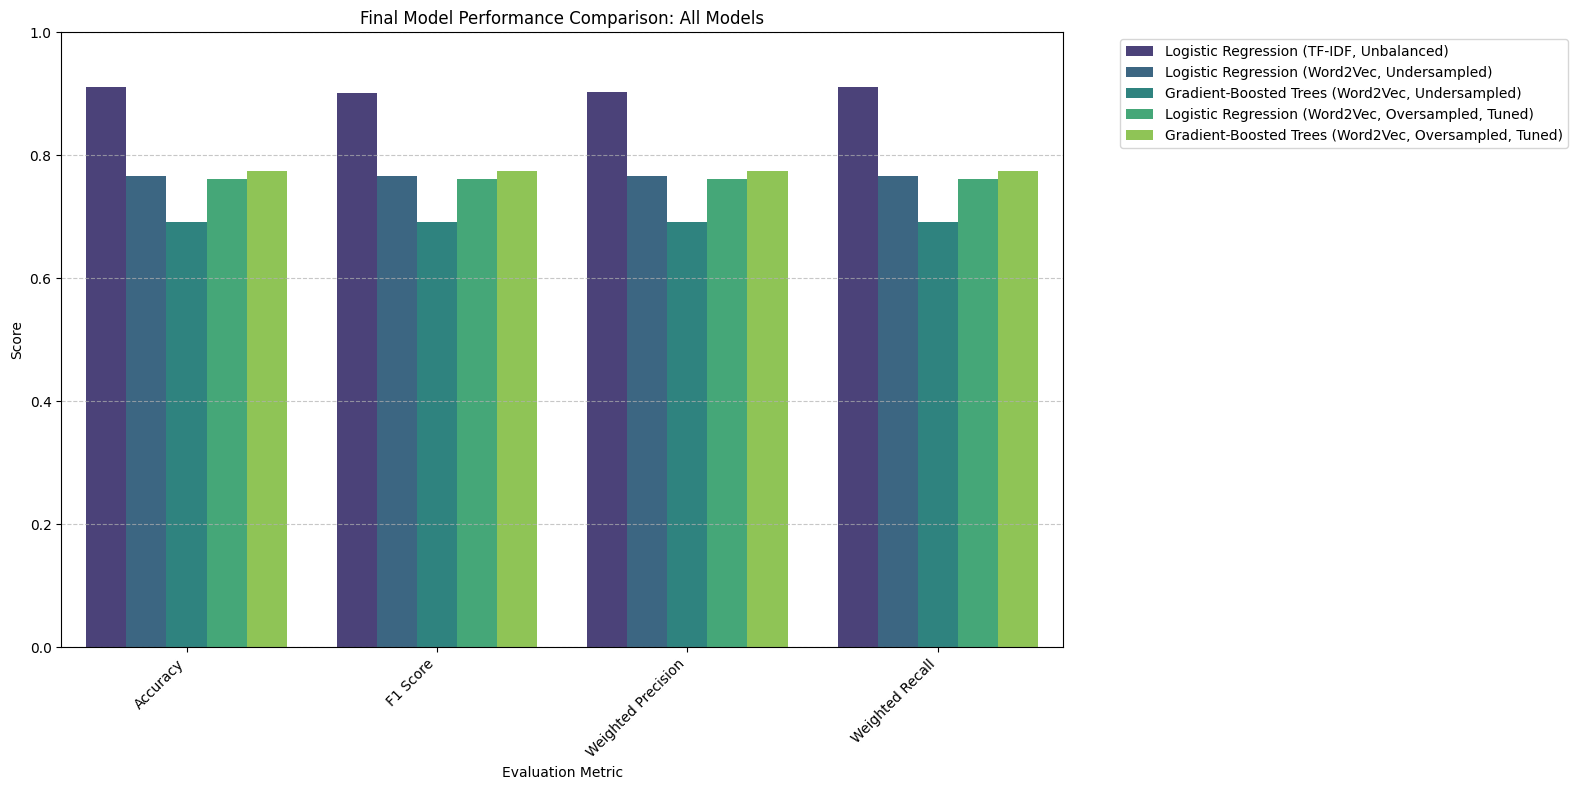

Visualized final model performance comparison.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

metrics_final = {
    "Model": [
        "Logistic Regression (TF-IDF, Unbalanced)",
        "Logistic Regression (Word2Vec, Undersampled)",
        "Gradient-Boosted Trees (Word2Vec, Undersampled)",
        "Logistic Regression (Word2Vec, Oversampled, Tuned)",
        "Gradient-Boosted Trees (Word2Vec, Oversampled, Tuned)"
    ],
    "Accuracy": [
        accuracy,
        accuracy_lr_balanced,
        accuracy_gbt,
        accuracy_lr_oversampled,
        accuracy_gbt_oversampled
    ],
    "F1 Score": [
        f1_score,
        f1_score_lr_balanced,
        f1_score_gbt,
        f1_score_lr_oversampled,
        f1_score_gbt_oversampled
    ],
    "Weighted Precision": [
        weighted_precision,
        weighted_precision_lr_balanced,
        weighted_precision_gbt,
        weighted_precision_lr_oversampled,
        weighted_precision_gbt_oversampled
    ],
    "Weighted Recall": [
        weighted_recall,
        weighted_recall_lr_balanced,
        weighted_recall_gbt,
        weighted_recall_lr_oversampled,
        weighted_recall_gbt_oversampled
    ]
}

performance_comparison_df_final = pd.DataFrame(metrics_final)

print("Final Model Performance Comparison:")
print(performance_comparison_df_final.to_markdown(index=False))

# Visualize the final comparison
performance_comparison_df_melted_final = performance_comparison_df_final.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(16, 8))
sns.barplot(
    x="Metric",
    y="Score",
    hue="Model",
    data=performance_comparison_df_melted_final,
    palette="viridis"
)

plt.ylim(0, 1.0) # Scores are typically between 0 and 1
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.title("Final Model Performance Comparison: All Models")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("Visualized final model performance comparison.")

## Class-Weighted Logistic Regression with N-grams



In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, lit, trim
from pyspark.ml.feature import Tokenizer, StopWordsRemover, NGram, HashingTF, IDF, StringIndexer
from pyspark.ml import Pipeline
from google.colab import drive

# Mount Google Drive with force_remount to ensure it's accessible
drive.mount('/content/drive', force_remount=True)

# Re-initialize SparkSession if it's not active or needs to be refreshed
spark = (SparkSession.builder
         .appName("Books EDA")
         .config("spark.driver.memory", "8g")
         .getOrCreate())

# Re-load ratings_df as it was not found in the current context or for robustness
ratings_df = spark.read.parquet(
    "/content/drive/MyDrive/Data_mining/clean/ratings_clean.parquet"
)

# Redefine sentiment_df from a previous step
positive_reviews = ratings_df.filter(col("review_score_num") >= 4).withColumn("sentiment_label", lit("positive"))
negative_reviews = ratings_df.filter(col("review_score_num") <= 2).withColumn("sentiment_label", lit("negative"))
sentiment_df = positive_reviews.union(negative_reviews)
sentiment_df = sentiment_df.filter(col("review/text").isNotNull() & (trim(col("review/text")) != ""))

# 1. Calculate the total number of reviews
total_reviews = sentiment_df.count()
print(f"Total reviews in sentiment_df: {total_reviews}")

# 2. Count the number of positive reviews and negative reviews
positive_count = sentiment_df.filter(col("sentiment_label") == "positive").count()
negative_count = sentiment_df.filter(col("sentiment_label") == "negative").count()

print(f"Positive reviews count: {positive_count}")
print(f"Negative reviews count: {negative_count}")

# 3. Calculate the class weight for the 'positive' class
class_weight_positive = total_reviews / (2 * positive_count)

# 4. Calculate the class weight for the 'negative' class
class_weight_negative = total_reviews / (2 * negative_count)

print(f"Class weight for positive: {class_weight_positive:.4f}")
print(f"Class weight for negative: {class_weight_negative:.4f}")

# 5. Create a new column named `class_weights` in `sentiment_df`
sentiment_df_with_weights = sentiment_df.withColumn(
    "class_weights",
    when(col("sentiment_label") == "positive", lit(class_weight_positive))
    .otherwise(lit(class_weight_negative))
)

print("sentiment_df with 'class_weights' column created.")
sentiment_df_with_weights.select("sentiment_label", "class_weights").show(5)

# 6-13. Implement text processing pipeline
tokenizer = Tokenizer(inputCol="review/text", outputCol="words")
stopwords_remover = StopWordsRemover(inputCol="words", outputCol="filtered_words")
ngram = NGram(n=2, inputCol="filtered_words", outputCol="bigrams") # Added NGram for bigrams
hashing_tf = HashingTF(inputCol="bigrams", outputCol="raw_features", numFeatures=262144) # Changed input to bigrams
idf = IDF(inputCol="raw_features", outputCol="features")
label_indexer = StringIndexer(inputCol="sentiment_label", outputCol="label")

pipeline = Pipeline(stages=[tokenizer, stopwords_remover, ngram, hashing_tf, idf, label_indexer])

# 14. Fit the pipeline to the sentiment_df_with_weights and transform
vectorized_df_ngram = pipeline.fit(sentiment_df_with_weights).transform(sentiment_df_with_weights)

# 15. Print schema and show rows
print("\nSchema of vectorized_df_ngram:")
vectorized_df_ngram.printSchema()
print("\nFirst 5 rows of vectorized_df_ngram (showing relevant columns):")
vectorized_df_ngram.select("review/text", "sentiment_label", "class_weights", "features", "label").show(5, truncate=False)


Mounted at /content/drive
Total reviews in sentiment_df: 2728739
Positive reviews count: 2377309
Negative reviews count: 351430
Class weight for positive: 0.5739
Class weight for negative: 3.8823
sentiment_df with 'class_weights' column created.
+---------------+------------------+
|sentiment_label|     class_weights|
+---------------+------------------+
|       positive|0.5739134037687149|
|       positive|0.5739134037687149|
|       positive|0.5739134037687149|
|       positive|0.5739134037687149|
|       positive|0.5739134037687149|
+---------------+------------------+
only showing top 5 rows

Schema of vectorized_df_ngram:
root
 |-- Id: string (nullable = true)
 |-- Title: string (nullable = true)
 |-- Price: string (nullable = true)
 |-- User_id: string (nullable = true)
 |-- review/score: string (nullable = true)
 |-- review/summary: string (nullable = true)
 |-- review/text: string (nullable = true)
 |-- review_score_num: double (nullable = true)
 |-- sentiment_label: string (nu

## Train Logistic Regression (N-gram, Class Weighted)


In [ ]:
training_df_ngram, test_df_ngram = vectorized_df_ngram.randomSplit([0.8, 0.2], seed=42)

from pyspark.ml.classification import LogisticRegression

lr_ngram = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    weightCol="class_weights",
    regParam=0.01,
    elasticNetParam=0.0
)
lr_ngram_model = lr_ngram.fit(training_df_ngram)

print("Data split into training and testing sets, and Logistic Regression model with N-gram features and class weights trained.")
print(f"Training data count: {training_df_ngram.count()}")
print(f"Test data count: {test_df_ngram.count()}")

Data split into training and testing sets, and Logistic Regression model with N-gram features and class weights trained.
Training data count: 2182626
Test data count: 546113


In [ ]:
predictions_lr_ngram = lr_ngram_model.transform(test_df_ngram)
print("Predictions generated on the test set using Logistic Regression model with N-gram features and class weights.")

from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.mllib.evaluation import MulticlassMetrics # for confusion matrix
from pyspark.sql.functions import abs

# Evaluate accuracy, F1-score, weighted precision, weighted recall
evaluator_lr_ngram = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

accuracy_lr_ngram = evaluator_lr_ngram.evaluate(predictions_lr_ngram, {evaluator_lr_ngram.metricName: "accuracy"})
print(f"LR (N-gram, Weighted) Model Accuracy: {accuracy_lr_ngram:.4f}")

f1_score_lr_ngram = evaluator_lr_ngram.evaluate(predictions_lr_ngram, {evaluator_lr_ngram.metricName: "f1"})
print(f"LR (N-gram, Weighted) Model F1 Score: {f1_score_lr_ngram:.4f}")

weighted_precision_lr_ngram = evaluator_lr_ngram.evaluate(predictions_lr_ngram, {evaluator_lr_ngram.metricName: "weightedPrecision"})
print(f"LR (N-gram, Weighted) Model Weighted Precision: {weighted_precision_lr_ngram:.4f}")

weighted_recall_lr_ngram = evaluator_lr_ngram.evaluate(predictions_lr_ngram, {evaluator_lr_ngram.metricName: "weightedRecall"})
print(f"LR (N-gram, Weighted) Model Weighted Recall: {weighted_recall_lr_ngram:.4f}")

# Calculate Confusion Matrix
# Convert predictions and labels to RDD for MulticlassMetrics
predictionAndLabels = predictions_lr_ngram.select("prediction", "label").rdd.map(tuple)
metrics = MulticlassMetrics(predictionAndLabels)

# Get confusion matrix
confusion_matrix = metrics.confusionMatrix().toArray()
print("\nConfusion Matrix (Rows = Actual, Columns = Predicted):")
print(confusion_matrix)

# Calculate Mean Absolute Error (MAE)
mae_lr_ngram = predictions_lr_ngram.withColumn("abs_error", abs(col("label") - col("prediction"))).agg({"abs_error": "avg"}).collect()[0][0]
print(f"\nLR (N-gram, Weighted) Model Mean Absolute Error (MAE): {mae_lr_ngram:.4f}")

Predictions generated on the test set using Logistic Regression model with N-gram features and class weights.
LR (N-gram, Weighted) Model Accuracy: 0.8735
LR (N-gram, Weighted) Model F1 Score: 0.8837
LR (N-gram, Weighted) Model Weighted Precision: 0.9030
LR (N-gram, Weighted) Model Weighted Recall: 0.8735


/usr/local/lib/python3.12/dist-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(



Confusion Matrix (Rows = Actual, Columns = Predicted):
[[423154.  52236.]
 [ 16833.  53890.]]

LR (N-gram, Weighted) Model Mean Absolute Error (MAE): 0.1265


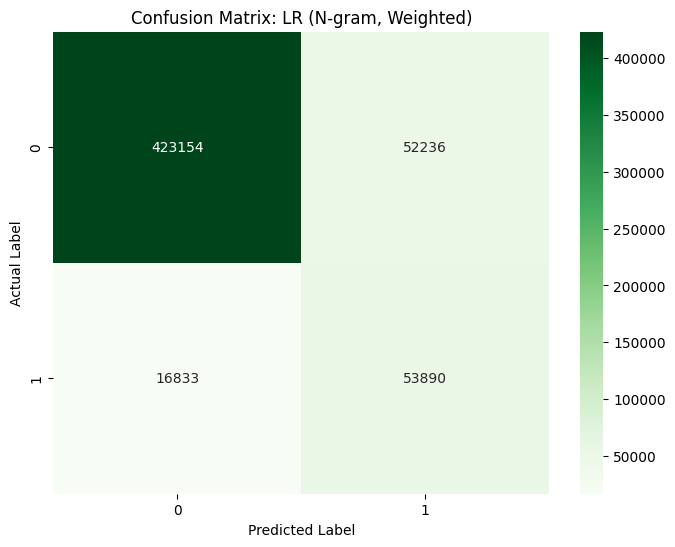

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from pyspark.ml.functions import vector_to_array


plt.figure(figsize=(8, 6))

sns.heatmap(confusion_matrix, annot=True, fmt='g', cmap='Greens')
plt.title('Confusion Matrix: LR (N-gram, Weighted)')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()



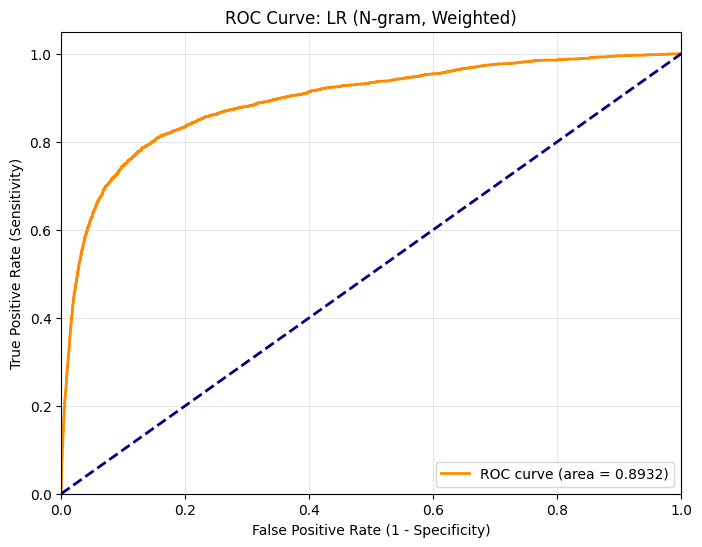

In [ ]:
df_roc = predictions_lr_ngram.select("label", "probability") \
    .sample(False, 0.05, seed=42) \
    .withColumn("prob_positive", vector_to_array("probability")[1]) \
    .toPandas()

fpr, tpr, thresholds = roc_curve(df_roc["label"], df_roc["prob_positive"])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve: LR (N-gram, Weighted)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

UNSUPERVISED LEARNING: CLUSTERING


---



In [ ]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF
from pyspark.ml import Pipeline
from pyspark.sql.functions import col

# 1. Taking a data sample (20%) so the algorithm runs quickly
df_kmeans = sentiment_df.sample(withReplacement=False, fraction=0.2, seed=42)

# 2. Creating a vectorization process (TF-IDF), similar to your Logistic Regression
tokenizer_km = Tokenizer(inputCol="review/text", outputCol="words")
stopwords_remover_km = StopWordsRemover(inputCol="words", outputCol="filtered_words")
hashing_tf_km = HashingTF(inputCol="filtered_words", outputCol="raw_features", numFeatures=5000)
idf_km = IDF(inputCol="raw_features", outputCol="features")

# 3. Defining the K-Means model (dividing reviews into 3 groups/clusters)
# You can change k=3 to e.g., k=5 if you want to find more groups
kmeans = KMeans(k=3, seed=42, featuresCol="features", predictionCol="cluster")

# 4. Building and training the Pipeline
pipeline_km = Pipeline(stages=[tokenizer_km, stopwords_remover_km, hashing_tf_km, idf_km, kmeans])

print("Training the K-Means model...")
kmeans_model = pipeline_km.fit(df_kmeans)

# 5. Assigning reviews to specific clusters (0, 1, or 2)
predictions = kmeans_model.transform(df_kmeans)

# 6. Evaluation - calculating the Silhouette Score
# Score from -1 to 1. The closer to 1, the better separated the clusters are
evaluator = ClusteringEvaluator(featuresCol="features", predictionCol="cluster")
silhouette = evaluator.evaluate(predictions)
print(f"\nSilhouette Score (clustering quality): {silhouette:.4f}")

# 7. Let's see how the reviews (positive vs negative) are distributed across clusters
print("\nSentiment distribution in individual clusters:")
predictions.groupBy("cluster", "sentiment_label").count().orderBy("cluster", "sentiment_label").show()

# 8. Previewing texts so you can assess what characterizes each cluster
print("\n--- Sample of reviews from Cluster 0 ---")
predictions.filter(col("cluster") == 0).select("review/text").show(3, truncate=110)

print("\n--- Sample of reviews from Cluster 1 ---")
predictions.filter(col("cluster") == 1).select("review/text").show(3, truncate=110)

print("\n--- Sample of reviews from Cluster 2 ---")
predictions.filter(col("cluster") == 2).select("review/text").show(3, truncate=110)

NameError: name 'sentiment_df' is not defined

Step 1: Processing text into TF-IDF vectors...
Step 2: Searching for the optimal 'k' on vectorized data...
For k=2 Silhouette Score is: 0.5722
For k=3 Silhouette Score is: 0.5690
For k=4 Silhouette Score is: 0.3567
For k=5 Silhouette Score is: 0.3562


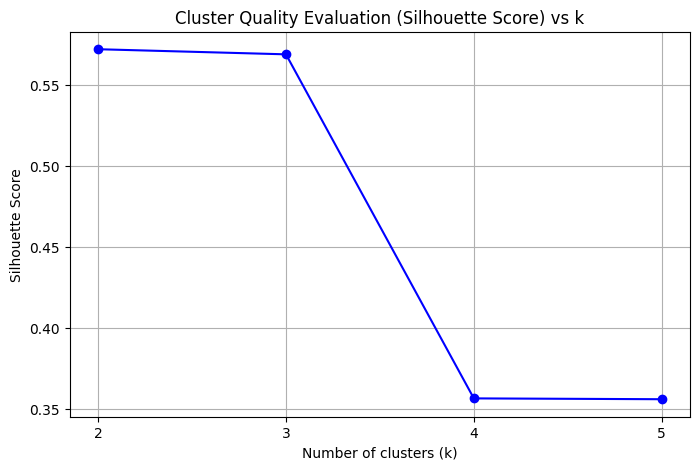

In [ ]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml import Pipeline
import matplotlib.pyplot as plt


tokenizer_km = Tokenizer(inputCol="review/text", outputCol="words")
stopwords_remover_km = StopWordsRemover(inputCol="words", outputCol="filtered_words")
hashing_tf_km = HashingTF(inputCol="filtered_words", outputCol="raw_features", numFeatures=5000)
idf_km = IDF(inputCol="raw_features", outputCol="features")

text_pipeline = Pipeline(stages=[tokenizer_km, stopwords_remover_km, hashing_tf_km, idf_km])

text_model = text_pipeline.fit(df_kmeans)
df_features = text_model.transform(df_kmeans)

df_features.cache()


silhouette_scores = []
k_values = [2, 3, 4, 5]

for k in k_values:
    kmeans_temp = KMeans(k=k, seed=42, featuresCol="features", predictionCol="cluster")

    model_temp = kmeans_temp.fit(df_features)
    preds_temp = model_temp.transform(df_features)

    evaluator = ClusteringEvaluator(featuresCol="features", predictionCol="cluster")
    score = evaluator.evaluate(preds_temp)
    silhouette_scores.append(score)
    print(f"For k={k} Silhouette Score is: {score:.4f}")

df_features.unpersist()

plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='o', linestyle='-', color='b')
plt.title('Cluster Quality Evaluation (Silhouette Score) vs k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.grid(True)
plt.show()

Dimensionality reduction to 2D using PCA...


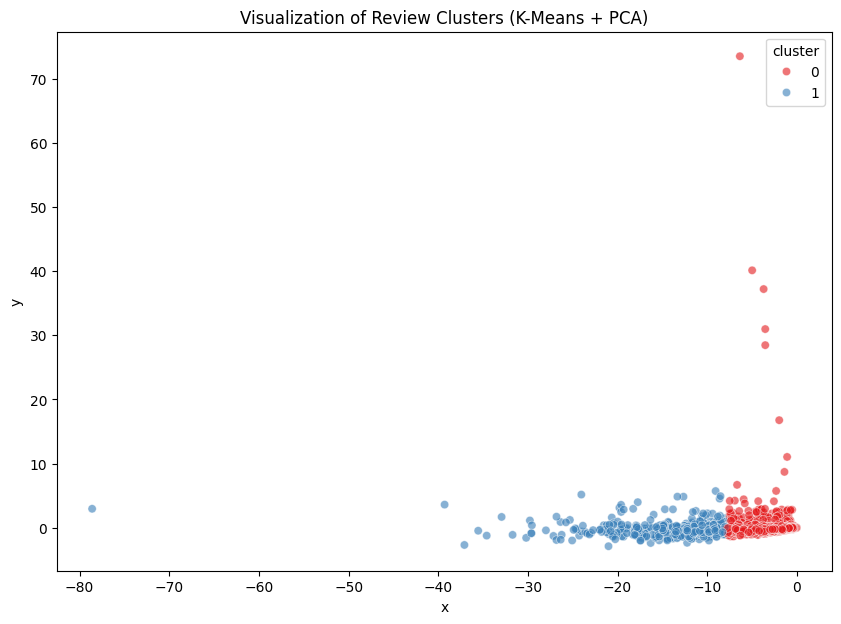

In [ ]:
from pyspark.ml.feature import PCA
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("Dimensionality reduction to 2D using PCA...")
pca = PCA(k=2, inputCol="features", outputCol="pca_features")
pca_model = pca.fit(predictions)
pca_result = pca_model.transform(predictions)

pdf_pca = pca_result.select("pca_features", "cluster", "sentiment_label").sample(fraction=0.05, seed=42).limit(5000).toPandas()

pdf_pca['x'] = pdf_pca['pca_features'].apply(lambda v: v[0])
pdf_pca['y'] = pdf_pca['pca_features'].apply(lambda v: v[1])

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pdf_pca, x='x', y='y', hue='cluster', palette='Set1', alpha=0.6)
plt.title('Visualization of Review Clusters (K-Means + PCA)')
plt.show()

In [ ]:
from pyspark.sql.functions import length, avg, min, max, stddev

# Adding a column with text length and calculating statistics for clusters
cluster_stats = predictions.withColumn("text_len", length("review/text")) \
    .groupBy("cluster") \
    .agg(
        avg("text_len").alias("avg_char_length"),
        stddev("text_len").alias("stddev_length"),
        min("text_len").alias("min_length"),
        max("text_len").alias("max_length")
    ).orderBy("cluster")

print("\nCluster Profiling based on text length:")
cluster_stats.show()


Cluster Profiling based on text length:
+-------+------------------+------------------+----------+----------+
|cluster|   avg_char_length|     stddev_length|min_length|max_length|
+-------+------------------+------------------+----------+----------+
|      0|  422.268728231256|274.39861466339454|         1|      2165|
|      1|1854.1734913793102| 850.4513159646925|       309|     16351|
|      2|11811.458333333334| 7017.765158814832|      2499|     20608|
+-------+------------------+------------------+----------+----------+

